In [1]:
import json
import pandas as pd

In [2]:
# Load benchmark results

with open('../benchmark/ross_cubic_jacs_v1.0.1.dat') as stream:
    cubic = json.loads(stream.read())

with open('../benchmark/ross_dodecahedron_jacs_v1.6_openmm8.1.2.dat') as stream:
    dodec = json.loads(stream.read())

with open('../benchmark/ross_dodecahedron_jacs_v1.6_openmm8.2.dat') as stream:
    dodec_plus = json.loads(stream.read())

with open('../benchmark/ross_dodecahedron_jacs_v1.6_openmm8.2_mps0.dat') as stream:
    dodec_plus_mps1 = json.loads(stream.read())

with open('../benchmark/ross_dodecahedron_jacs_v1.6_openmm8.2_mps1.dat') as stream:
    dodec_plus_mps2 = json.loads(stream.read())

with open('../benchmark/ross_dodecahedron_jacs_v1.6_openmm8.2_mps2.dat') as stream:
    dodec_plus_mps3 = json.loads(stream.read())

/tmp/ipykernel_19479/72365174.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["OpenFE v1.0 + OpenMM 8.1.2", "OpenFE v1.7 + OpenMM 8.1.2", "OpenFE v1.7 + OpenMM 8.2", "OpenFE v1.7 + OpenMM 8.2 + MPS"], rotation=40)


([<matplotlib.axis.YTick at 0x7ae457691340>,
 [Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7')])

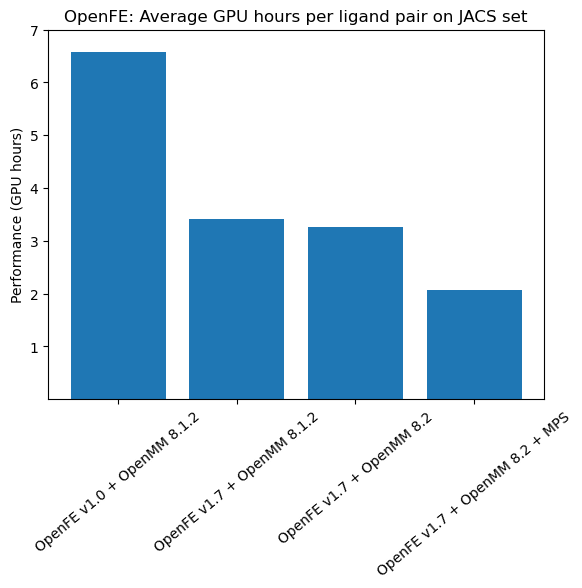

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.bar(
    x=["v1.0 + OpenMM 8.1.2", "v1.7 + OpenMM 8.1.2", "v1.7 + OpenMM 8.2", "v1.7 + OpenMM 8.2 + MPS"],
    height=[6.58, 3.41, 3.26, 2.07],
)
#ax = df.plot(x='systems', y=['T4', 'L4', 'A10G', 'A30', 'A100', 'L40S'], kind='bar', figsize=(12,8))
ax.set_xticklabels(["OpenFE v1.0 + OpenMM 8.1.2", "OpenFE v1.7 + OpenMM 8.1.2", "OpenFE v1.7 + OpenMM 8.2", "OpenFE v1.7 + OpenMM 8.2 + MPS"], rotation=40)
plt.title('OpenFE: Average GPU hours per ligand pair on JACS set')
#plt.xlabel('GPU hours')
plt.ylabel('Performance (GPU hours)')
plt.yticks([1, 2, 3, 4, 5, 6, 7])
# plt.savefig('per_benchmark_descriptive.png', bbox_inches="tight")

In [25]:
6.58/2.07

3.1787439613526574

/tmp/ipykernel_254996/2843000424.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["OpenFE v1.0 + OpenMM 8.1.2", "OpenFE v1.7 + OpenMM 8.2", "OpenFE v1.7 + OpenMM 8.2 + MPS"], rotation=15)


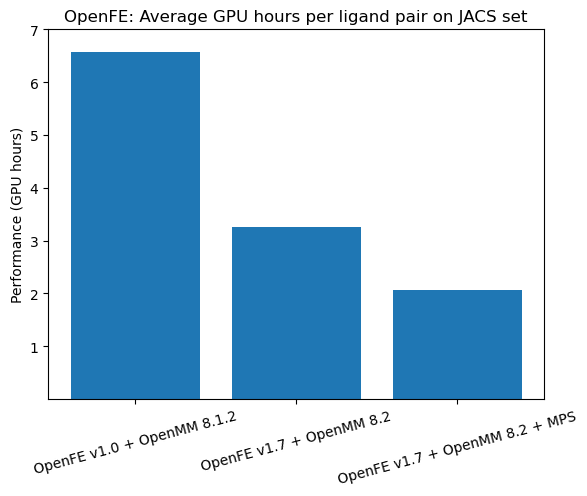

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.bar(
    x=["OpenFE v1.0 + OpenMM 8.1.2", "OpenFE v1.7 + OpenMM 8.2", "OpenFE v1.7 + OpenMM 8.2 + MPS"],
    height=[6.58, 3.26, 2.07],
)
#ax = df.plot(x='systems', y=['T4', 'L4', 'A10G', 'A30', 'A100', 'L40S'], kind='bar', figsize=(12,8))
ax.set_xticklabels(["OpenFE v1.0 + OpenMM 8.1.2", "OpenFE v1.7 + OpenMM 8.2", "OpenFE v1.7 + OpenMM 8.2 + MPS"], rotation=15)
plt.title('OpenFE: Average GPU hours per ligand pair on JACS set')
#plt.xlabel('GPU hours')
plt.ylabel('Performance (GPU hours)')
plt.yticks([1, 2, 3, 4, 5, 6, 7])
plt.savefig('per_benchmark_presentation.png', bbox_inches="tight")

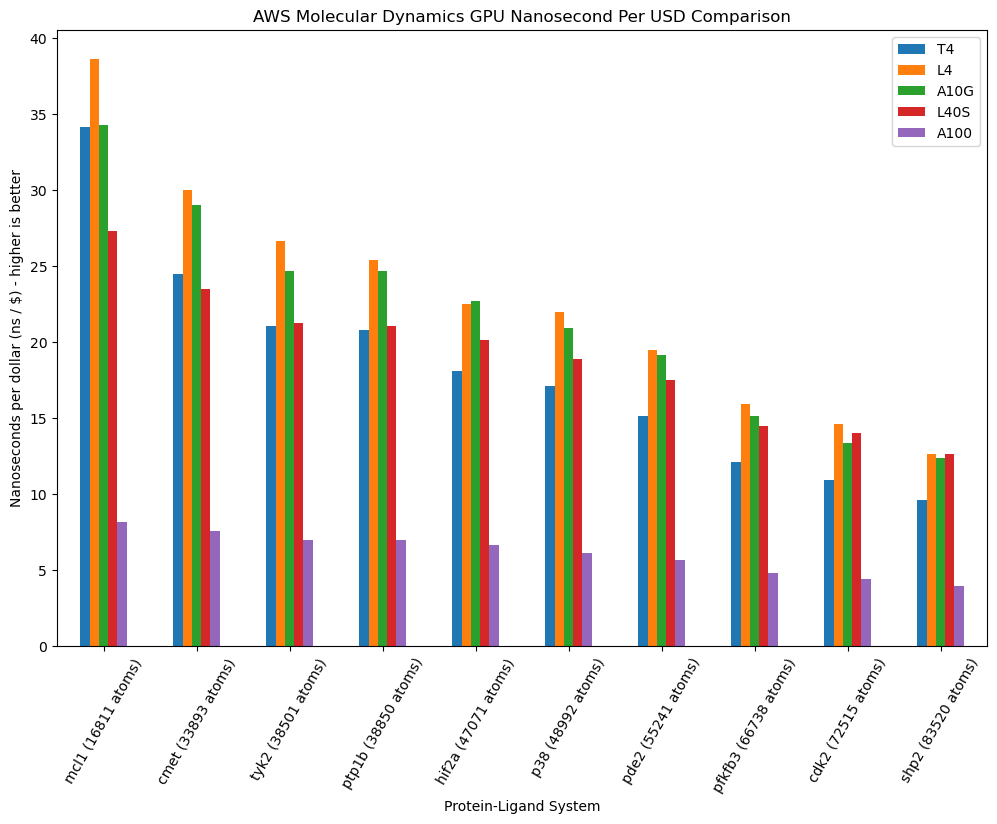

In [7]:
import matplotlib.pyplot as plt

ax = df.plot(x='systems', y=['T4', 'L4', 'A10G', 'L40S', 'A100'], kind='bar', figsize=(12,8))
ax.set_xticklabels(df['systems'], rotation=60)
plt.title('AWS Molecular Dynamics GPU Nanosecond Per USD Comparison')
plt.xlabel('Protein-Ligand System')
plt.ylabel('Nanoseconds per dollar (ns / $) - higher is better')
plt
plt.savefig('openmm_md_benchmark_costs.png', bbox_inches="tight")

In [8]:
# Load rbfe benchmark results

with open('L40S_openmm8.1.2_rbfe_benchmark.out') as stream:
    L40_rbfe_data = json.loads(stream.read())

with open('A30_openmm8.1.2_rbfe_benchmark.out') as stream:
    A30_rbfe_data = json.loads(stream.read())

In [9]:
plot_data = {
    'systems': [f"{sys} ({benchmark[sys]["atoms"]} atoms)" for sys in benchmark],
    'atoms': [benchmark[sys]['atoms'] for sys in benchmark],
    'A30': A30_rbfe_data.values(),
    'L40S': L40_rbfe_data.values(),
}
df = pd.DataFrame(plot_data)
df.sort_values('atoms', inplace=True)

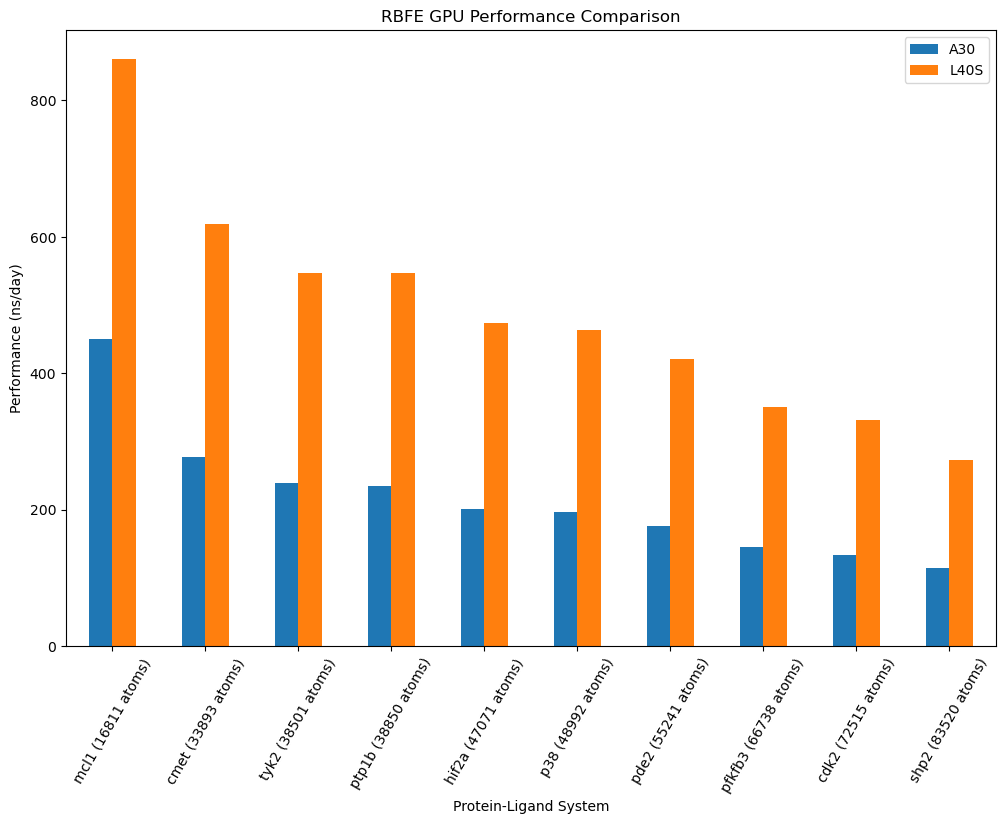

In [11]:
ax = df.plot(x='systems', y=['A30', 'L40S'], kind='bar', figsize=(12,8))
ax.set_xticklabels(df['systems'], rotation=60)
plt.title('RBFE GPU Performance Comparison')
plt.xlabel('Protein-Ligand System')
plt.ylabel('Performance (ns/day)')
plt.savefig('openmm_rbfe_benchmark.png', bbox_inches="tight")